In [11]:
import numpy as np
import matplotlib.pyplot as plt 
import numba as nb
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

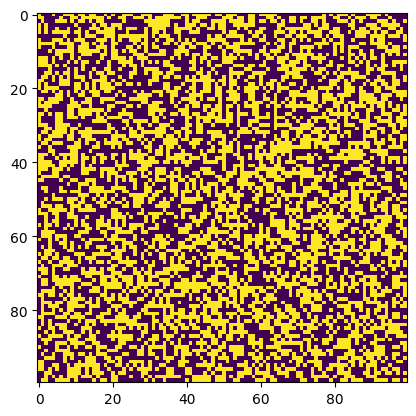

In [12]:
#parametry symulacji:
N = 100   #rozmiar siatki
J = 1.0   #stała oddziaływania  
B = 0.0      #pole magnetyczne
beta = 0.44  #parametr temperaturowy
M=100 #makrokroki

#macierz-losowanie położenia na siatce -spinu
state=np.random.choice([-1,1],size=(N,N))
plt.imshow(state)

In [13]:
#delta E
#każdy spin ma 8 sąsiadów, sj _nn nearest neighbors
from numba import njit

@njit
def delta_E(S, x, y, N, J, B):
    gora  = S[(x - 1) % N, y]
    dol   = S[(x + 1) % N, y]
    lewo  = S[x, (y - 1) % N]
    prawo = S[x, (y + 1) % N]
    
   #przekątne
    lewo_gora   = S[(x - 1) % N, (y - 1) % N]
    prawo_gora  = S[(x - 1) % N, (y + 1) % N]
    lewo_dol    = S[(x + 1) % N, (y - 1) % N]
    prawo_dol   = S[(x + 1) % N, (y + 1) % N]
    
    suma_nn = gora + dol + lewo + prawo + lewo_gora + prawo_gora + lewo_dol + prawo_dol
    dE = 2 * S[x, y] * (J * suma_nn + B)
    
    return dE


In [14]:
#makrokrok
@njit
def makrokrok(S, N, J, B, beta):
    for _ in range(N * N): #całe pole maceirzy dostępne
        x = np.random.randint(0, N)
        y = np.random.randint(0, N) #losowanie wsp w macierzy
        
        dE = delta_E(S, x, y, N, J, B) #wywołanie dE
        
        if dE <0:
            S[x,y] = (-1)* S[x,y] #odwrócenie spinu
        else:
            prawdop = np.exp(-beta*dE)
            szansa=np.random.rand() #losowanie z zakresu 0,1 rozkald jendostajny
            if szansa < prawdop:
                S[x,y] = (-1)* S[x,y] #odwrócenie spinu
    return S
   


In [15]:
#delta E bez numby
#każdy spin ma 8 sąsiadów, sj _nn nearest neighbors
def delta_E_bez_numby(S, x, y, N, J, B):
    gora  = S[(x - 1) % N, y]
    dol   = S[(x + 1) % N, y]
    lewo  = S[x, (y - 1) % N]
    prawo = S[x, (y + 1) % N]
    
   #przekątne
    lewo_gora   = S[(x - 1) % N, (y - 1) % N]
    prawo_gora  = S[(x - 1) % N, (y + 1) % N]
    lewo_dol    = S[(x + 1) % N, (y - 1) % N]
    prawo_dol   = S[(x + 1) % N, (y + 1) % N]
    
    suma_nn = gora + dol + lewo + prawo + lewo_gora + prawo_gora + lewo_dol + prawo_dol
    dE = 2 * S[x, y] * (J * suma_nn + B)
    
    return dE


In [16]:
#makrokrok bez numby

def makrokrok_bez_numby(S, N, J, B, beta):
    for _ in range(N * N): #całe pole maceirzy dostępne
        x = np.random.randint(0, N)
        y = np.random.randint(0, N) #losowanie wsp w macierzy
        
        dE = delta_E_bez_numby(S, x, y, N, J, B) #wywołanie dE
        
        if dE <0:
            S[x,y] = (-1)* S[x,y] #odwrócenie spinu
        else:
            prawdop = np.exp(-beta*dE)
            szansa=np.random.rand() #losowanie z zakresu 0,1 rozkald jendostajny
            if szansa < prawdop:
                S[x,y] = (-1)* S[x,y] #odwrócenie spinu
    return S

In [17]:
#symulacja
import time  #do pomiaru czasu wykonania symulacji
def symulacja(S, N, J, B, beta, M,uzyj_numba=True):
    S=S.copy()
    hist_m=np.zeros(M) #historia mmagnetyzacji
    klatki_animacji = np.zeros((M, N, N)) #klatki animacji

    start_time = time.time() #poacztek liczenia czasu
    for i in range(M):
        if uzyj_numba:
            S = makrokrok(S, N, J, B, beta)
        else:
            S = makrokrok_bez_numby(S, N, J, B, beta)
    
        magnetyzacja = np.sum(S) / (N * N) 
        hist_m[i] = magnetyzacja
        klatki_animacji[i] = S.copy() #zapisanie klatki

    end_time = time.time()
    print('Czas wykonania:', end_time - start_time, 's dla uzyj_numba=', uzyj_numba)
    return hist_m, klatki_animacji #do wykresów


In [18]:
#porównanie wydajności
print('Symulacja z numba:')
hist_m_numba, klatki_numba = symulacja(state, N, J, B, beta, M,uzyj_numba=True)

print('Symulacja bez numba:')

hist_m_bez_numby, klatki_bez_numby = symulacja(state, N, J, B, beta, M,uzyj_numba=False)

Symulacja z numba:
Czas wykonania: 1.0179216861724854 s dla uzyj_numba= True
Symulacja bez numba:
Czas wykonania: 23.14911198616028 s dla uzyj_numba= False


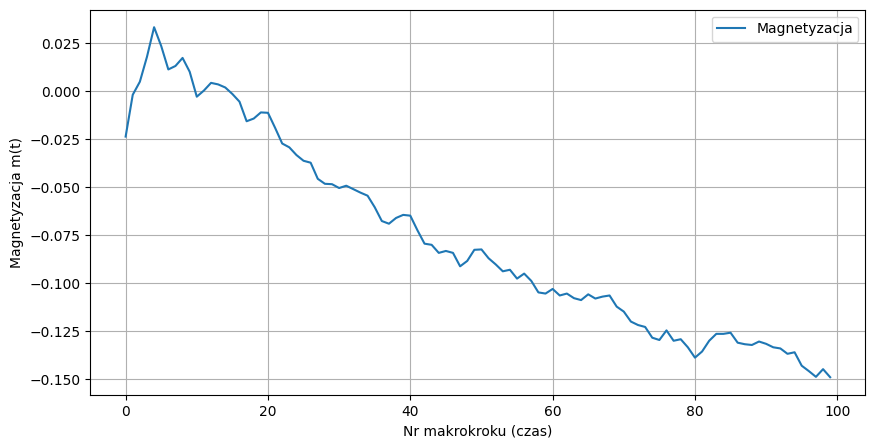

In [19]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


plt.figure(figsize=(10, 5))


plt.plot(hist_m_numba, label='Magnetyzacja')

plt.xlabel('Nr makrokroku (czas)')
plt.ylabel("Magnetyzacja m(t)")
plt.grid(True) 
plt.legend()
plt.show()

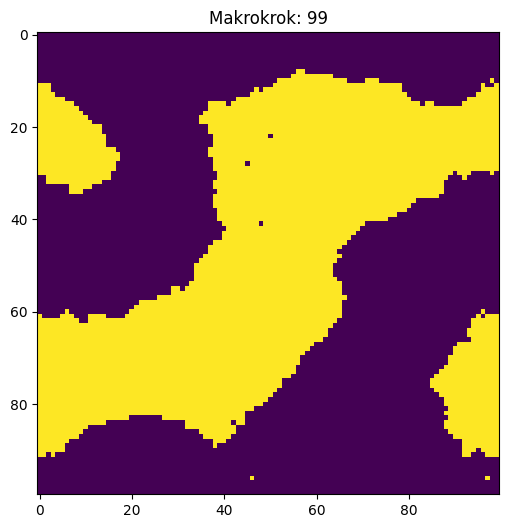

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

obraz = ax.imshow(klatki_numba[0], vmin=-1, vmax=1)
ax.set_title("Ewolucja spinów")

def aktualizuj(numer_klatki):
    obraz.set_data(klatki_numba[numer_klatki])#odświeżanie klatek
    ax.set_title(f"Makrokrok: {numer_klatki}")#aktualizacja tytulu zeby widziec makrokrok
    return [obraz]

animacja = FuncAnimation(fig, aktualizuj, frames=M, interval=50, blit=True)
#frames-ile klatek =tyle ile makrokroków
#plt.close() 
HTML(animacja.to_jshtml())